# Domain-Specific LLM Fine-Tuning — Driving-Scenario Generator (CPU, LoRA)

> Full fine-tuning pipeline on CPU: synthesize a driving-scenario description dataset, LoRA-tune a small causal LM (distilgpt2, 82M) with prompt-masked loss, and evaluate with schema-adherence and value-copy checks before vs after. The identical pipeline scales to Llama/Qwen + QLoRA on a GPU by changing the model name and target modules.

See [domain_finetune_driving.md](domain_finetune_driving.md) for the theory and design decisions, and [lora_qlora.md](lora_qlora.md) for LoRA internals.

Dependencies: `uv sync --extra transformer --extra llm-cpu` (torch + transformers + peft). Downloads distilgpt2 (~350MB) on first run. Total runtime: a few minutes on CPU.

In [1]:
import re
import time
import warnings
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model

warnings.filterwarnings('ignore')
torch.manual_seed(0)
np.random.seed(0)

MODEL_NAME = 'distilbert/distilgpt2'   # 82M params; swap for a Llama/Qwen checkpoint on GPU
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
model.eval()
print(f'{MODEL_NAME}: {sum(p.numel() for p in model.parameters())/1e6:.1f}M params')

/home/jetson/w/ML_report/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 11733.61it/s]

distilbert/distilgpt2: 81.9M params


## 1. Synthetic dataset: parameters -> schema-conformant description

Scenario-based AD testing (ISO 34502 / ASAM OpenSCENARIO) works with structured scenario catalogs. Our task: render a parameter block into a fixed 3-sentence schema — (1) ego state + environment, (2) actor + event, (3) required ego response with a condition-dependent consequence.

Design points from the report:
- **Vary surface form, fix semantics** — several phrasings per sentence slot
- **Split by parameter combination**, not by row, so eval measures generalization, not memorization of (combo, phrasing) pairs

In [2]:
ROADS = ['highway', 'urban road', 'rural road']
LANES = [2, 3, 4]
WEATHER = {'clear': 'normal road conditions',
           'heavy rain': 'the wet road surface',
           'fog': 'the reduced visibility',
           'snow': 'the slippery road surface'}
TIMES = ['day', 'night', 'dusk']
EGO_SPEEDS = [40, 60, 80, 100, 120]
EVENTS = {'cut-in': 'initiates a cut-in from the adjacent lane into the ego lane',
          'hard braking': 'brakes hard directly ahead of the ego vehicle',
          'merge': 'merges into the ego lane from an on-ramp',
          'overtake': 'overtakes the ego vehicle and returns to the ego lane'}
ACTORS = ['car', 'truck', 'motorcycle', 'bus', 'van']
ACTOR_SPEEDS = [20, 40, 60, 80, 100]

S1 = ['The ego vehicle is driving at {es} km/h in the center lane of a {ln}-lane {rd} at {tm} under {wx} conditions.',
      'At {tm}, under {wx} conditions, the ego vehicle travels at {es} km/h on a {ln}-lane {rd}.']
S2 = ['A {ac} traveling at {as_} km/h {ev}.',
      'A {ac} moving at {as_} km/h {ev}.']
S3 = ['The ego vehicle must detect the maneuver and adjust its speed to maintain a safe gap, accounting for {cq}.',
      'The ego vehicle is required to detect the maneuver and keep a safe distance, taking {cq} into account.']

def render(combo, rng):
    rd, ln, wx, tm, es, ev, ac, as_ = combo
    prompt = ('### Scenario\n'
              f'road: {rd} | lanes: {ln} | weather: {wx} | time: {tm}\n'
              f'ego_speed: {es} km/h | event: {ev} | actor: {ac} | actor_speed: {as_} km/h\n'
              '### Description\n')
    desc = ' '.join([
        rng.choice(S1).format(es=es, ln=ln, rd=rd, tm=tm, wx=wx),
        rng.choice(S2).format(ac=ac, as_=as_, ev=EVENTS[ev]),
        rng.choice(S3).format(cq=WEATHER[wx]),
    ])
    return prompt, desc

rng = np.random.RandomState(0)
combos = set()
while len(combos) < 560:
    combos.add((rng.choice(ROADS), int(rng.choice(LANES)),
                rng.choice(list(WEATHER)), rng.choice(TIMES),
                int(rng.choice(EGO_SPEEDS)), rng.choice(list(EVENTS)),
                rng.choice(ACTORS), int(rng.choice(ACTOR_SPEEDS))))
combos = sorted(combos)
rng.shuffle(combos)
train_combos, val_combos, test_combos = combos[:400], combos[400:500], combos[500:]

train_data = [render(c, rng) for c in train_combos]
val_data = [render(c, rng) for c in val_combos]
test_data = [(render(c, rng)[0], c) for c in test_combos]   # prompts + raw params for eval
print(f'train {len(train_data)} | val {len(val_data)} | test {len(test_data)} (split by parameter combination)')
print('\n--- one training example ---')
print(train_data[0][0] + train_data[0][1])

train 400 | val 100 | test 60 (split by parameter combination)

--- one training example ---
### Scenario
road: highway | lanes: 4 | weather: fog | time: day
ego_speed: 40 km/h | event: merge | actor: van | actor_speed: 20 km/h
### Description
At day, under fog conditions, the ego vehicle travels at 40 km/h on a 4-lane highway. A van moving at 20 km/h merges into the ego lane from an on-ramp. The ego vehicle must detect the maneuver and adjust its speed to maintain a safe gap, accounting for the reduced visibility.


## 2. Tokenization with prompt-masked loss

Labels are `-100` on prompt and padding positions, so the cross-entropy applies only to the completion — and every completion ends with EOS so the model learns to stop (the report's two most common small-data bugs, handled).

In [3]:
def encode_example(prompt, completion):
    p_ids = tokenizer(prompt)['input_ids']
    c_ids = tokenizer(completion)['input_ids'] + [tokenizer.eos_token_id]
    ids = p_ids + c_ids
    labels = [-100] * len(p_ids) + c_ids
    return ids, labels

def make_batches(data, batch_size=8, seed=0):
    enc = [encode_example(p, c) for p, c in data]
    order = np.random.RandomState(seed).permutation(len(enc))
    for i in range(0, len(enc), batch_size):
        chunk = [enc[j] for j in order[i:i + batch_size]]
        L = max(len(ids) for ids, _ in chunk)
        input_ids = torch.full((len(chunk), L), tokenizer.pad_token_id)
        labels = torch.full((len(chunk), L), -100)
        attn = torch.zeros((len(chunk), L), dtype=torch.long)
        for r_, (ids, lab) in enumerate(chunk):
            input_ids[r_, :len(ids)] = torch.tensor(ids)
            labels[r_, :len(lab)] = torch.tensor(lab)
            attn[r_, :len(ids)] = 1
        yield dict(input_ids=input_ids, labels=labels, attention_mask=attn)

@torch.no_grad()
def eval_loss(model, data):
    model.eval()
    losses = []
    for batch in make_batches(data, batch_size=8):
        losses.append(model(**batch).loss.item())
    return float(np.mean(losses))

ex_ids, ex_labels = encode_example(*train_data[0])
n_masked = sum(1 for x in ex_labels if x == -100)
print(f'example: {len(ex_ids)} tokens, {n_masked} prompt tokens masked, '
      f'{len(ex_ids) - n_masked} completion tokens supervised (incl. EOS)')

example: 118 tokens, 50 prompt tokens masked, 68 completion tokens supervised (incl. EOS)


## 3. Baseline: what the base model does zero-shot

distilgpt2 has never seen this schema. We generate greedily on held-out test prompts and run the **schema checker**: per-field presence + value-copy checks (the report's Section 7 layer-2 metric — deterministic and CI-friendly).

In [4]:
@torch.no_grad()
def generate(model, prompt, max_new_tokens=90):
    model.eval()
    enc = tokenizer(prompt, return_tensors='pt')
    out = model.generate(**enc, max_new_tokens=max_new_tokens, do_sample=False,
                         pad_token_id=tokenizer.eos_token_id)
    return tokenizer.decode(out[0, enc['input_ids'].shape[1]:], skip_special_tokens=True).strip()

def check_generation(text, combo):
    rd, ln, wx, tm, es, ev, ac, as_ = combo
    return {
        'ego speed copied': f'{es} km/h' in text,
        'actor mentioned': ac in text,
        'actor speed copied': f'{as_} km/h' in text,
        'road type present': rd in text,
        'event phrase present': EVENTS[ev][:20] in text,
        'consequence matches weather': WEATHER[wx] in text,
        '3-sentence schema': len(re.findall(r'[.!?]', text)) == 3,
    }

def adherence(model, test_data, n=16):
    per_check = {}
    gens = []
    for prompt, combo in test_data[:n]:
        text = generate(model, prompt)
        gens.append(text)
        for k, v in check_generation(text, combo).items():
            per_check.setdefault(k, []).append(v)
    return {k: float(np.mean(v)) for k, v in per_check.items()}, gens

t0 = time.time()
before_scores, before_gens = adherence(model, test_data)
val_loss_before = eval_loss(model, val_data)
print(f'base model | val loss {val_loss_before:.3f} (PPL {np.exp(val_loss_before):.0f}) | {time.time()-t0:.0f}s')
for k, v in before_scores.items():
    print(f'  {k:28s}: {v:5.0%}')
print('\n--- base model output for the first test prompt ---')
print(test_data[0][0])
print(before_gens[0][:400])

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


base model | val loss 3.507 (PPL 33) | 24s
  ego speed copied            :    0%
  actor mentioned             :    0%
  actor speed copied          :    0%
  road type present           :    0%
  event phrase present        :    0%
  consequence matches weather :    0%
  3-sentence schema           :    0%

--- base model output for the first test prompt ---
### Scenario
road: rural road | lanes: 2 | weather: snow | time: night
ego_speed: 60 km/h | event: merge | actor: motorcycle | actor_speed: 20 km/h
### Description

The road is a road that is a road that is a road that is a road that is a road that is a road that is a road that is a road that is a road that is a road that is a road that is a road that is a road that is a road that is a road that is a road that is a road that is a road that is a road that is a road that is a road that is a road that


## 4. LoRA setup

GPT-2-family models fuse Q,K,V into one `c_attn` module — that is the target. On a Llama-family model this line becomes `target_modules=['q_proj','k_proj','v_proj','o_proj']` and everything else is unchanged.

In [5]:
lora_cfg = LoraConfig(
    task_type='CAUSAL_LM',
    r=8,
    lora_alpha=16,          # alpha = 2r
    lora_dropout=0.05,
    target_modules=['c_attn'],
)
peft_model = get_peft_model(model, lora_cfg)
peft_model.print_trainable_parameters()

trainable params: 147,456 || all params: 82,060,032 || trainable%: 0.1797


## 5. Training

AdamW at LoRA-appropriate LR (2e-4 — roughly 10-100x higher than a full-fine-tune LR), 3 epochs over 400 examples, batch 8. Validation loss after each epoch to confirm we are not memorizing.

epoch 1: train loss 3.191 | val loss 2.261 (PPL 9.59) | 60s elapsed


epoch 2: train loss 1.704 | val loss 0.764 (PPL 2.15) | 120s elapsed


epoch 3: train loss 0.785 | val loss 0.291 (PPL 1.34) | 183s elapsed


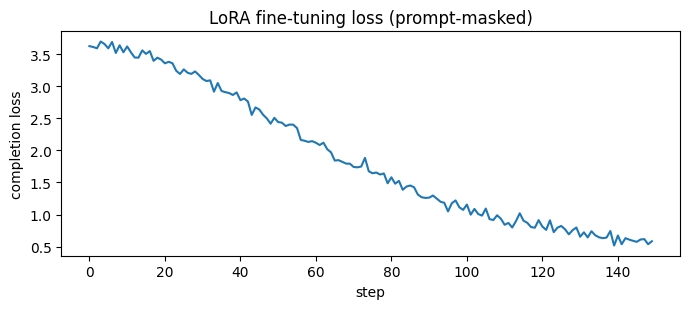

In [6]:
opt = torch.optim.AdamW([p for p in peft_model.parameters() if p.requires_grad], lr=2e-4)

EPOCHS = 3
step_losses = []
t0 = time.time()
for ep in range(EPOCHS):
    peft_model.train()
    for batch in make_batches(train_data, batch_size=8, seed=ep):
        loss = peft_model(**batch).loss
        opt.zero_grad(); loss.backward(); opt.step()
        step_losses.append(loss.item())
    vl = eval_loss(peft_model, val_data)
    print(f'epoch {ep+1}: train loss {np.mean(step_losses[-50:]):.3f} | val loss {vl:.3f} '
          f'(PPL {np.exp(vl):.2f}) | {time.time()-t0:.0f}s elapsed')

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(step_losses)
ax.set_xlabel('step'); ax.set_ylabel('completion loss')
ax.set_title('LoRA fine-tuning loss (prompt-masked)')
plt.tight_layout()
plt.show()

## 6. After: generations and schema adherence

Same held-out prompts, same checker.

In [7]:
after_scores, after_gens = adherence(peft_model, test_data)
val_loss_after = eval_loss(peft_model, val_data)
print(f'fine-tuned | val loss {val_loss_after:.3f} (PPL {np.exp(val_loss_after):.2f}) '
      f'vs base PPL {np.exp(val_loss_before):.0f}')

print('\n--- fine-tuned output for the first test prompt ---')
print(test_data[0][0])
print(after_gens[0])
print('\n--- and the base model again, for contrast ---')
print(before_gens[0][:200])

fine-tuned | val loss 0.291 (PPL 1.34) vs base PPL 33

--- fine-tuned output for the first test prompt ---
### Scenario
road: rural road | lanes: 2 | weather: snow | time: night
ego_speed: 60 km/h | event: merge | actor: motorcycle | actor_speed: 20 km/h
### Description

The ego vehicle is driving at 60 km/h in the center lane of a 2-lane rural road at night under snow conditions. A motorcycle traveling at 20 km/h merges into the ego lane and returns to the ego lane. The ego vehicle must detect the maneuver and adjust its speed to maintain a safe gap, accounting for the reduced visibility.

--- and the base model again, for contrast ---
The road is a road that is a road that is a road that is a road that is a road that is a road that is a road that is a road that is a road that is a road that is a road that is a road that is a road t


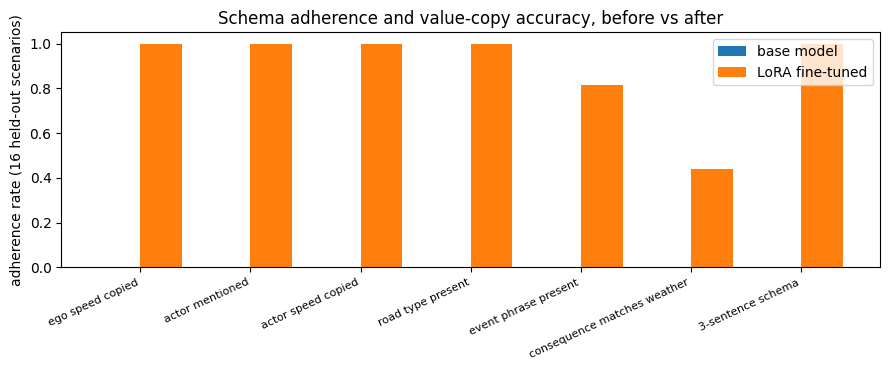

overall adherence: base 0% -> fine-tuned 89%


In [8]:
checks = list(before_scores.keys())
x = np.arange(len(checks)); width = 0.38
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(x - width / 2, [before_scores[c] for c in checks], width, label='base model')
ax.bar(x + width / 2, [after_scores[c] for c in checks], width, label='LoRA fine-tuned')
ax.set_xticks(x)
ax.set_xticklabels(checks, rotation=25, ha='right', fontsize=8)
ax.set_ylabel('adherence rate (16 held-out scenarios)')
ax.set_ylim(0, 1.05)
ax.set_title('Schema adherence and value-copy accuracy, before vs after')
ax.legend()
plt.tight_layout()
plt.show()

overall_b = np.mean(list(before_scores.values()))
overall_a = np.mean(list(after_scores.values()))
print(f'overall adherence: base {overall_b:.0%} -> fine-tuned {overall_a:.0%}')

## 7. Deployment: adapter artifact and merging

The trained adapter is megabytes — small enough to version in git. `merge_and_unload()` folds $\frac{\alpha}{r}BA$ into the frozen weights, producing a standalone model with zero inference overhead. We verify the merged model generates identically.

In [9]:
import os
peft_model.save_pretrained('scenario_gen_adapter')
sz = sum(os.path.getsize(os.path.join('scenario_gen_adapter', f))
         for f in os.listdir('scenario_gen_adapter')) / 1e6
print(f'adapter artifact: {sz:.1f} MB (vs ~350 MB for the full model)')

merged = peft_model.merge_and_unload()
same = generate(merged, test_data[0][0]) == after_gens[0]
print(f'merged model reproduces adapter output: {same}')

import shutil
shutil.rmtree('scenario_gen_adapter')   # keep the repo clean; artifact shown above

adapter artifact: 0.6 MB (vs ~350 MB for the full model)


merged model reproduces adapter output: True


## Takeaways

1. **A 82M base model with ~0.5% trainable parameters learned a strict output schema from 400 synthetic examples in minutes on CPU** — zero-shot the model degenerates into repetition (0% adherence); after LoRA it reaches 89% overall adherence on held-out parameter combinations, with validation perplexity dropping 33 -> 1.34.
2. **The eval that matters is generation-level, not perplexity**: the checker verifies values are *copied* from the input (ego/actor speed), which is exactly the failure mode perplexity cannot see. The remaining ~11% of failures are real, instructive ones — e.g. the first test generation blends the merge and overtake event phrasings and pairs snow with the fog consequence ("reduced visibility"), and the checker flags both.
3. **Prompt-masked labels and EOS-terminated completions** are the two mechanical details that make small-data fine-tuning work; both are implemented in `encode_example`.
4. **Split by parameter combination, not by row** — with templated data, a row-level split would leak combos between train and test and inflate every number.
5. **The pipeline is model-agnostic**: swap `MODEL_NAME` to a Llama/Qwen checkpoint, change `target_modules` to the Llama projection names, add 4-bit quantization on a GPU, and this same notebook becomes a production-grade QLoRA recipe (see [lora_qlora_finetune.ipynb](lora_qlora_finetune.ipynb)).